Imports

In [146]:
#Log in to huggingface hub
from huggingface_hub import login
import os
from dotenv import load_dotenv
load_dotenv()
login(token = os.getenv("HFToken"))
#HFToken = [your token] in .env

In [147]:
""" Official evaluation script for v1.1 of the SQuAD dataset. """

import re
import string
from collections import Counter


def normalize_answer(s):
    """Lower text and remove punctuation, articles and extra whitespace."""

    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def white_space_fix(text):
        return " ".join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def f1_score(prediction, ground_truth):
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0
    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

In [148]:
#Model Initiallization
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
model_id = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id,padding_side="left")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="cuda:0",dtype=torch.bfloat16)

[transformers] loading configuration file config.json from cache at C:\Users\Leo\.cache\huggingface\hub\models--meta-llama--Llama-3.2-1B-Instruct\snapshots\9213176726f574b556790deb65791e0c5aa438b6\config.json
[transformers] Model config LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "dtype": "bfloat16",
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 8192,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 16,
  "num_key_value_heads": 8,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "factor": 32.0,
    "high_freq_factor": 4.0,
    "low_freq_factor": 1.0,
    "original_max_position_embeddings": 8192,
    "rope_theta": 500000.0,


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] loading configuration file generation_config.json from cache at C:\Users\Leo\.cache\huggingface\hub\models--meta-llama--Llama-3.2-1B-Instruct\snapshots\9213176726f574b556790deb65791e0c5aa438b6\generation_config.json
[transformers] Generate config GenerationConfig {
  "bos_token_id": 128000,
  "do_sample": true,
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "temperature": 0.6,
  "top_p": 0.9
}



In [149]:
#Dataset Initiallization
from datasets import load_dataset
ds = load_dataset("rajpurkar/squad")

In [223]:
#Prompt Generation
prompt = [[
    {
        "role": "system",
        "content":"Answer in as few words as possible. Output only the entity name and nothing else."
        #"content": "You are a precise calculator. Output ONLY the final numerical answer. Do not include words, units, explanations, or punctuation."
    },
    {
        "role": "user",
        "content":  f"Context:\n{context}\n\nQuestion:\n{question}"
    }
]for context,question in zip(ds["train"]["context"],ds["train"]["question"])]
questions = 100
input = tokenizer.apply_chat_template(
    prompt[0:questions],
    tokenize = True,
    add_generation_prompt=True,
    padding=True,
    return_tensors="pt",
    clean_up_tokenization_spaces=False
).to("cuda:0")
input_length = input["input_ids"].shape[1]

In [224]:
#Output Saving
from transformers import logging
logging.set_verbosity_info()
raw_output = model.generate(
    **input,
    max_new_tokens= 100,
    do_sample=False,
    temperature=1,
    pad_token_id=tokenizer.pad_token_id,
    tokenizer=tokenizer,
    return_dict_in_generate=True,
    output_logits=True,
    output_scores=True
    )
output = raw_output.sequences
#for i in range(questions):
 #   write.append(tokenizer.decode(output[i][input_length:],skip_special_tokens=True))
#json.dump(write,f)

In [225]:
#f1 data
predictions = []
for i in range(questions):
   predictions.append(tokenizer.decode(output[i][input_length:],skip_special_tokens=True,clean_up_tokenization_spaces=True))
f1 = torch.zeros(questions)
for i in range(questions):
    f1[i] = f1_score(predictions[i],ds["train"]["answers"][i]["text"][0])
f1 = f1.cpu()

In [226]:
#confidence calculation
logits = raw_output.scores[-50:]
tensor_logits = torch.stack(logits)
prob = tensor_logits.softmax(dim=2)
confidence = torch.zeros(questions)
max_prob, max_ids = torch.max(prob,dim=2)
confidence = torch.prod(max_prob,dim=0).cpu()

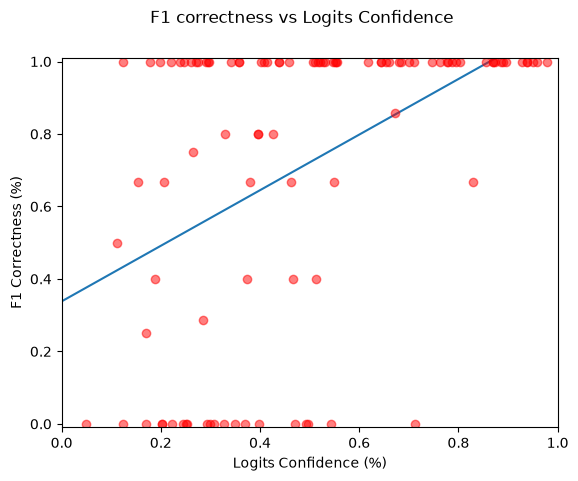

In [227]:
import matplotlib.pyplot as plt
slope, intercept = np.polyfit(confidence,f1,1)
plt.suptitle('F1 correctness vs Logits Confidence')
plt.xlabel('Logits Confidence (%)')
plt.ylabel('F1 Correctness (%)')
plt.xlim(0,1)
plt.ylim(-0.01,1.01)
x = np.linspace(0,1,100)
y = slope*x+intercept
plt.plot(x,y)
plt.plot(confidence,f1,'ro',alpha=0.5)